# Example-26: Frequency estimation from complex data

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# TbT data can be complex, in this case data type should be passed for Data(), Data.from_file() and Data.from_epics

# f < 1/2

w = Window.from_cosine(4096, 1.0, dtype=torch.float64, device=device)
c = torch.cos(2.0*numpy.pi*0.12*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
s = torch.sin(2.0*numpy.pi*0.12*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
d = torch.stack([c + 1j*s])
d = Data.from_data(w, d)
d.window_apply()
f = Frequency(d, f_range=(0.0, 1.0))
f('parabola')
print(f.frequency)

# f > 1/2

w = Window.from_cosine(4096, 1.0, dtype=torch.float64, device=device)
c = torch.cos(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
s = torch.sin(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
d = torch.stack([c + 1j*s])
d = Data.from_data(w, d)
d.window_apply()
f = Frequency(d, f_range=(0.0, 1.0))
f('parabola')
print(f.frequency)

tensor([1.200000000000e-01], dtype=torch.float64)
tensor([8.800000000000e-01], dtype=torch.float64)


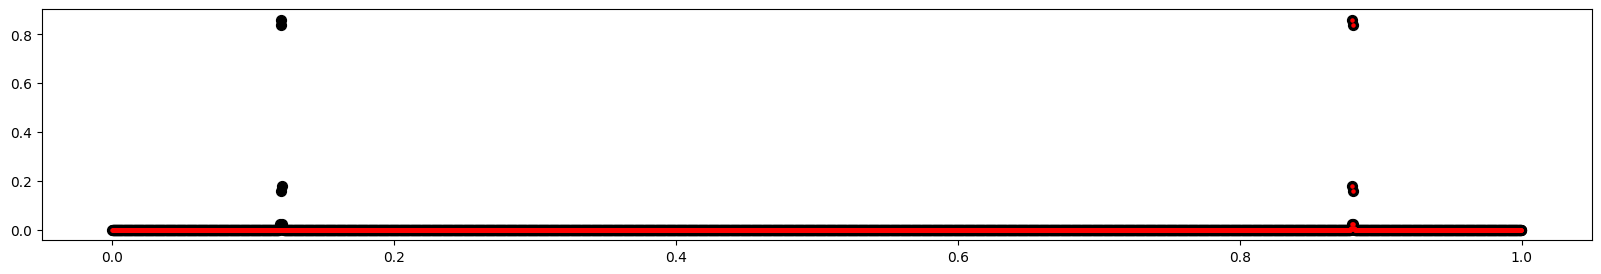

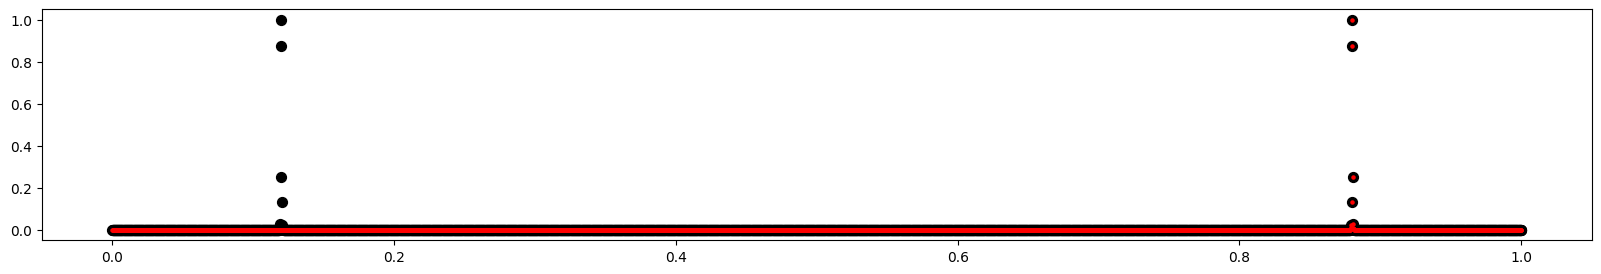

In [4]:
# Compare amplitude spectrum for real and complex data
# Note, correct iflag for nufft is -1 for complex data

# Real signal (FFT and NUFFT)

w = Window.from_cosine(4096, 1.0, dtype=torch.float64, device=device)
c = torch.cos(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
s = torch.sin(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
d = torch.stack([c])
d = Data.from_data(w, d)
d.window_apply()
f1 = Frequency(d, f_range=(0.0, 1.0))
f1('parabola')
d.reset()
g1, s1 = f1.compute_joined_spectrum(length=w.length, f_range=(0.0, 1.0), position=numpy.array([1.0]), iflag=-1)

# Complex signal (FFT and NUFFT)

w = Window.from_cosine(4096, 1.0, dtype=torch.float64, device=device)
c = torch.cos(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
s = torch.sin(2.0*numpy.pi*0.88*torch.linspace(1, w.length, w.length, dtype=torch.complex128, device=device))
d = torch.stack([c + 1j*s])
d = Data.from_data(w, d)
d.window_apply()
f2 = Frequency(d, f_range=(0.0, 1.0))
f2('parabola')
d.reset()
g2, s2 = f2.compute_joined_spectrum(length=w.length, f_range=(0.0, 1.0), position=numpy.array([1.0]), iflag=-1)

# Plot results (FFT spectum)

plt.figure(figsize=(20, 3))
plt.scatter(f1.fft_grid.cpu().numpy(), (f1.fft_spectrum[0]/f1.ffrft_spectrum[0].max()).cpu().numpy(), s=50.0, color='black')
plt.scatter(f2.fft_grid.cpu().numpy(), (f2.fft_spectrum[0]/f2.ffrft_spectrum[0].max()).cpu().numpy(), s=05.0, color='red')
plt.show()

# Plot results (NUFFT spectum)

plt.figure(figsize=(20, 3))
plt.scatter(g1.real.cpu().numpy(), s1.real.cpu().numpy(), s=50.0, color='black')
plt.scatter(g2.real.cpu().numpy(), s2.real.cpu().numpy(), s=05.0, color='red')
plt.show()

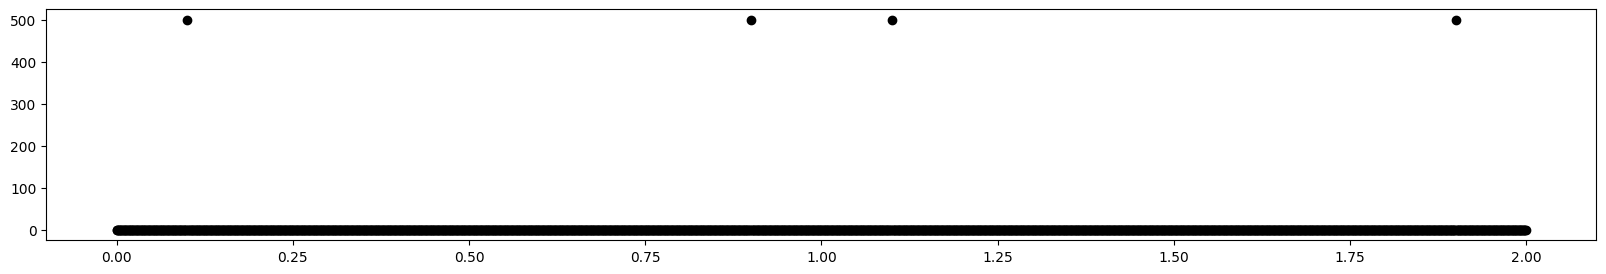

In [5]:
# Insert zeros

length = 1000
signal = torch.cos(2.0*numpy.pi*0.1*torch.linspace(1, length, length, dtype=torch.complex128, device=device))

insert = 1

mask = torch.zeros(1 + insert, dtype=torch.float64, device=device)
mask[0] = 1.0

signal = (mask*signal.reshape(-1, 1)).flatten().reshape(1, -1)

w = Window.from_cosine(length*(1 + insert), 0.0, dtype=torch.float64, device=device)
d = Data.from_data(w, signal)
d.window_apply()
f = Frequency(d)
f('fft')

plt.figure(figsize=(20, 3))
plt.scatter(f.fft_grid.cpu().numpy()*(1 + insert), f.fft_spectrum[0].cpu().numpy(), color='black')
plt.show()